# Imported required libraries

In [336]:
# Data Handling & System Utilities
import os
import random
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import string
import kaggle as kg
from dotenv import load_dotenv
import time

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import (FuncFormatter, MaxNLocator, PercentFormatter)
import seaborn as sns
import missingno as msno
from IPython.display import (HTML, Markdown, display)

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [337]:
# Statistical analysis and Hypothesis testing
from scipy import stats
from scipy.stats import (gamma, ks_2samp)
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from scipy.stats import norm
from numpy.linalg import matrix_rank

# Machine learning & Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error,
    mean_squared_error, r2_score)
from scipy.stats import ks_2samp
from sklearn.utils.class_weight import compute_class_weight
from yellowbrick.target import ClassBalance

In [338]:
# Display settings & Warning configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Reset to default after use (recommended practice)
# pd.reset_option('display.max_columns')
import warnings
warnings.filterwarnings("ignore")

# Importing Data

In [339]:
# Define the directory where the data is stored
base_path = r"C:/Users/danie/Downloads/Data Analytic/lending_club_data/preprocessed_data"

try:
    # Attempt to read the specific CSV files using os.path.join for path safety
    X_train = pd.read_csv(os.path.join(base_path, 'loan_inputs_train.csv'))
    y_train = pd.read_csv(os.path.join(base_path, 'loan_targets_train.csv'))
    X_test = pd.read_csv(os.path.join(base_path, 'loan_inputs_test.csv'))
    y_test = pd.read_csv(os.path.join(base_path, 'loan_targets_test.csv'))
    
except FileNotFoundError:
    print(f"Error: Could not find the files in '{base_path}'.")
    print("Please verify the directory path and ensure the files were exported correctly.")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

else:
    # Success confirmation and data verification
    print("Data successfully imported.")
    print("=" * 40)
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")
    print("=" * 40)

Data successfully imported.
X_train shape: (200000, 37)
y_train shape: (200000, 1)
X_test shape:  (50000, 37)
y_test shape:  (50000, 1)


In [340]:
# Dataset Previews
print("\n🚀 X_train preview (first 5 rows):")
display(X_train.head(5))

print("\n🎯 y_train preview (First 3 rows):")
display(y_train.head(5))


🚀 X_train preview (first 5 rows):


,funded_amnt,installment,total_acc,total_rev_hi_lim,CCF,total_rec_int,open_acc,revol_util,mths_since_issue_d,all_util,fico_mean,tot_cur_bal,pub_rec_bankruptcies,pub_rec,mort_acc,int_rate,mo_sin_rcnt_tl,mo_sin_rcnt_rev_tl_op,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc,inq_fi,inq_last_6mths,recovery_rate,dti,emp_length,term,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type,int_rate_tier
0,40000.00,902.37,32.00,47500.00,0.87,3916.10,11.00,50.80,17.00,52.00,742.00,169265.00,0.00,0.00,7.00,12.62,2.00,12.00,185.00,0.00,0.00,125000.00,5.00,0.00,0.00,21.20,0.00,60 months,C,C1,MORTGAGE,Verified,Credit card refinancing,NC,w,Individual,M (11 - 17%)
1,6200.00,186.72,17.00,33200.00,0.00,17.41,9.00,37.50,23.00,24.00,737.00,246474.00,1.00,1.00,2.00,5.32,12.00,12.00,267.00,0.00,0.00,85165.00,1.00,0.00,0.00,15.02,5.00,36 months,A,A1,MORTGAGE,Source Verified,Other,TX,w,Individual,L (5 - 11%)
2,6000.00,193.41,18.00,44900.00,0.45,790.10,10.00,23.10,22.00,23.00,752.00,10351.00,0.00,0.00,1.00,9.93,14.00,14.00,431.00,0.00,0.00,13992.00,1.00,0.00,0.00,25.90,10.00,36 months,B,B2,OWN,Not Verified,Credit card refinancing,FL,f,Individual,L (5 - 11%)
3,14400.00,342.96,44.00,22200.00,0.84,2169.39,15.00,32.30,15.00,30.00,682.00,111725.00,0.00,0.00,4.00,15.05,7.00,7.00,252.00,3.00,11.00,275000.00,4.00,0.00,0.00,17.40,4.00,60 months,C,C4,MORTGAGE,Not Verified,Credit card refinancing,VA,w,Individual,M (11 - 17%)
4,16000.00,351.00,25.00,43300.00,0.70,2876.26,7.00,18.60,24.00,19.00,737.00,216045.00,0.00,0.00,2.00,11.39,6.00,17.00,397.00,1.00,10.00,72000.00,0.00,0.00,0.00,33.97,0.00,60 months,B,B3,MORTGAGE,Not Verified,Major purchase,GA,w,Individual,M (11 - 17%)



🎯 y_train preview (First 3 rows):


,target
0,1.00
1,0.00
2,0.00
3,0.00
4,0.00


In [341]:
# Define columns to remove
cols_to_drop = ['inq_fi', 'total_rec_int', 'tot_cur_bal', 'mort_acc', 'earliest_cr_line', 'addr_state', 'int_rate_tier', 'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op']

# Create a dictionary to iterate through splits and their names
splits = {'Training': X_train, 'Testing': X_test}

print("🚀 Starting column removal...")

for name, df in splits.items():
    # Drop columns and update the dataframe in-place
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    
    # Verification: Check if columns still exist in the dataframe
    remaining_forbidden = [col for col in cols_to_drop if col in df.columns]
    
    if not remaining_forbidden:
        print(f"✅ {name} set: {cols_to_drop} successfully removed. (Remaining columns: {len(df.columns)})")
    else:
        print(f"❌ {name} set: Failed to remove {remaining_forbidden}")

# Final check
print(f"\nFinal Feature List (X_train): {X_train.columns.tolist()}")
print(f"\nFinal Feature List (X_test): {X_test.columns.tolist()}")

🚀 Starting column removal...
✅ Training set: ['inq_fi', 'total_rec_int', 'tot_cur_bal', 'mort_acc', 'earliest_cr_line', 'addr_state', 'int_rate_tier', 'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op'] successfully removed. (Remaining columns: 29)
✅ Testing set: ['inq_fi', 'total_rec_int', 'tot_cur_bal', 'mort_acc', 'earliest_cr_line', 'addr_state', 'int_rate_tier', 'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op'] successfully removed. (Remaining columns: 29)

Final Feature List (X_train): ['funded_amnt', 'installment', 'total_acc', 'total_rev_hi_lim', 'CCF', 'open_acc', 'revol_util', 'mths_since_issue_d', 'all_util', 'fico_mean', 'pub_rec_bankruptcies', 'pub_rec', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'mths_since_last_delinq', 'annual_inc', 'inq_last_6mths', 'recovery_rate', 'dti', 'emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type']

Final Feature List (X_test): ['funded_amnt', 'installment', 

In [342]:
# Previews and Outputs
print(f"Features columns ({X_train.shape[1]}): {X_train.columns.tolist()}\n")
print(f"Target columns ({y_train.shape[1]}): {y_train.columns.tolist()}\n")

Features columns (29): ['funded_amnt', 'installment', 'total_acc', 'total_rev_hi_lim', 'CCF', 'open_acc', 'revol_util', 'mths_since_issue_d', 'all_util', 'fico_mean', 'pub_rec_bankruptcies', 'pub_rec', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'mths_since_last_delinq', 'annual_inc', 'inq_last_6mths', 'recovery_rate', 'dti', 'emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type']

Target columns (1): ['target']



In [343]:
def compute_data_audit_summary(df_input, dataset_name="Dataset"):
    """
    Computes data types, missing value counts, and missing percentages 
    for columns that contain missing data.
    """
    summary = (
        df_input.dtypes.to_frame(name="Type")
        .join(pd.DataFrame({
            "Missing values": df_input.isna().sum(),
            "Percentage Missing": round(df_input.isna().mean() * 100, 2)
        }))
        # Filter to only keep columns that have 1 or more missing values
        .loc[lambda df: df["Missing values"] > 0]
        # Sort by the highest number of missing values
        .sort_values(by="Missing values", ascending=False))
    
    return summary

# Lits all columns with missing values (Train)
print("\n📝 X_TRAIN: All columns with missing values")
print("-" * 100)
X_train_summary = compute_data_audit_summary(X_train, "X_train")
display(X_train_summary) 

# Lits all columns with missing values (Test)
print("\n📝 X_TEST: All columns with missing values")
print("-" * 100)
X_test_summary = compute_data_audit_summary(X_test, "X_test")
display(X_test_summary)


📝 X_TRAIN: All columns with missing values
----------------------------------------------------------------------------------------------------


,Type,Missing values,Percentage Missing
all_util,float64,42,0.02



📝 X_TEST: All columns with missing values
----------------------------------------------------------------------------------------------------


,Type,Missing values,Percentage Missing
all_util,float64,13,0.03


In [344]:
# Fill missing values with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Verify remaining missing values
print("\nRemaining missing values in X_train:")
print(X_train.isna().sum().sum())

print("\nRemaining missing values in X_test:")
print(X_test.isna().sum().sum())


Remaining missing values in X_train:
0

Remaining missing values in X_test:
0


# Filtering defaulted account data

In [345]:
# Combined datasets for easier handling
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Isolate only loans that have actually defaulted, because LGD and EAD are defined conditional on default.
train_defaults = train_data[train_data['target'] == 1] # .isin([1]) also can work
test_defaults = test_data[test_data['target'] == 1]

# Preview the data
train_defaults

,funded_amnt,installment,total_acc,total_rev_hi_lim,CCF,open_acc,revol_util,mths_since_issue_d,all_util,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc,inq_last_6mths,recovery_rate,dti,emp_length,term,grade,sub_grade,home_ownership,verification_status,purpose,initial_list_status,application_type,target
0,40000.00,902.37,32.00,47500.00,0.87,11.00,50.80,17.00,52.00,742.00,0.00,0.00,12.62,185.00,0.00,0.00,125000.00,0.00,0.00,21.20,0.00,60 months,C,C1,MORTGAGE,Verified,Credit card refinancing,w,Individual,1.00
16,9000.00,282.82,23.00,47400.00,0.98,15.00,23.90,4.00,24.00,682.00,1.00,1.00,8.19,141.00,0.00,0.00,52000.00,2.00,0.00,8.79,10.00,36 months,A,A4,RENT,Not Verified,Credit card refinancing,w,Individual,1.00
43,15000.00,486.87,22.00,8800.00,0.94,16.00,28.00,19.00,70.00,662.00,0.00,0.00,30.17,139.00,3.00,6.00,52000.00,0.00,11.44,11.65,2.00,60 months,F,F3,OWN,Verified,Other,w,Individual,1.00
76,10000.00,389.19,18.00,7000.00,0.94,9.00,67.20,8.00,45.00,677.00,1.00,1.00,23.40,136.00,0.00,43.00,37000.00,2.00,0.00,16.32,10.00,36 months,E,E1,MORTGAGE,Verified,Debt consolidation,f,Joint App,1.00
87,12000.00,393.72,19.00,14300.00,0.95,8.00,74.90,27.00,70.00,672.00,0.00,0.00,30.74,207.00,0.00,38.00,48536.00,0.00,0.00,34.20,10.00,60 months,F,F5,RENT,Verified,Debt consolidation,f,Individual,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199913,12000.00,357.94,25.00,12200.00,0.96,11.00,29.60,10.00,73.00,702.00,0.00,0.00,25.81,167.00,0.00,32.00,39000.00,2.00,0.00,14.34,5.00,60 months,E,E4,RENT,Not Verified,Debt consolidation,w,Joint App,1.00
199932,3700.00,125.55,17.00,6900.00,0.86,11.00,76.20,25.00,74.00,662.00,0.00,1.00,13.49,145.00,1.00,20.00,65500.00,1.00,30.37,15.26,10.00,36 months,C,C2,RENT,Verified,Debt consolidation,f,Individual,1.00
199963,35000.00,1063.94,35.00,18200.00,0.98,9.00,70.10,11.00,66.00,662.00,0.00,0.00,26.77,229.00,1.00,3.00,125000.00,1.00,11.52,5.84,3.00,60 months,E,E5,MORTGAGE,Verified,Debt consolidation,w,Joint App,1.00
199967,5000.00,173.31,17.00,19100.00,0.77,11.00,26.40,25.00,26.00,692.00,0.00,0.00,14.99,236.00,0.00,0.00,14000.00,1.00,1.23,30.45,10.00,36 months,C,C4,RENT,Verified,Debt consolidation,w,Individual,1.00


In [346]:
# Overview of Dtype
train_defaults.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13633 entries, 0 to 199996
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   funded_amnt                  13633 non-null  float64
 1   installment                  13633 non-null  float64
 2   total_acc                    13633 non-null  float64
 3   total_rev_hi_lim             13633 non-null  float64
 4   CCF                          13633 non-null  float64
 5   open_acc                     13633 non-null  float64
 6   revol_util                   13633 non-null  float64
 7   mths_since_issue_d           13633 non-null  float64
 8   all_util                     13633 non-null  float64
 9   fico_mean                    13633 non-null  float64
 10  pub_rec_bankruptcies         13633 non-null  float64
 11  pub_rec                      13633 non-null  float64
 12  int_rate                     13633 non-null  float64
 13  mths_since_earliest_

In [347]:
# Summary statistics for Recovery Rate
train_defaults['recovery_rate'].describe()

count   13633.00
mean        3.83
std         6.41
min         0.00
25%         0.00
50%         0.00
75%         9.20
max        99.00
Name: recovery_rate, dtype: float64

In [348]:
# Ensure recovery_rate is decimal between 0 and 1
train_defaults['recovery_rate'] = train_defaults['recovery_rate'] / 100.0
test_defaults['recovery_rate'] = test_defaults['recovery_rate'] / 100.0

In [349]:
# Summary statistics for Credit Conversion Factor (CCF),
train_defaults['CCF'].describe()

count   13633.00
mean        0.82
std         0.14
min         0.00
25%         0.74
50%         0.85
75%         0.93
max         1.00
Name: CCF, dtype: float64

In [350]:
# Create a binary recovery flag to distinguish between loans with no recovered funds and loans where at least some amount was recovered.
train_defaults['recovery_rate_0_1'] = np.where(train_defaults['recovery_rate'] == 0, 0, 1).astype(float)
test_defaults['recovery_rate_0_1'] = np.where(test_defaults['recovery_rate'] == 0, 0, 1).astype(float)

# LGD Model

When loans default, many recover nothing at all (recovery = 0). Therefore, if we try to predict the percentage recovered with a single regression model, those zeros pull the regression line down and make the model useless for cases where some money is actually recovered.

1. First model (binary classification)
- Question: Will there be any recovery?
- Answer: Yes/No. This model learns the probability that an account recovers something > 0.

2. Second model (regression)
- Question: If there is some recovery, how much (as a percentage of the exposure)?
- Answer: A number between 0% and 100%. This model is trained only on cases where recovery actually happened (no zeros allowed).


| Stage   | Model Type          | Purpose                                    |
| ------- | ------------------- | ------------------------------------------ |
| Stage 1 | Logistic Regression | Predict whether meaningful recovery occurs |
| Stage 2 | Linear Regression   | Predict the magnitude of recovery          |

## The Classification Stage
- A substantial proportion of defaulted loans exhibit recovery rates at the boundary values of 0% (total loss) or 100% (full recovery). Standard regression models generally perform poorly when modelling outcomes concentrated at these extremes. Therefore, the objective of the first stage is to classify whether a meaningful loss is likely to occur by distinguishing loans with full recovery from those with partial or no recovery.

The first-stage model predicts the probability that the recovery outcome belongs to either:
- 1 → full recovery, or
- 0 → partial/no recovery.

**How to interpret the output:**
The model output is a probability value (e.g., 0.75). A higher probability indicates a greater likelihood of full recovery, whereas a lower probability suggests a higher likelihood of partial recovery or total loss. Loans associated with potential losses are then passed to the second-stage regression model to estimate the expected recovery severity more precisely.

In [351]:
# Isolate target variable
y_train = train_defaults['recovery_rate_0_1']
y_test = test_defaults['recovery_rate_0_1']

In [352]:
# Temporarily combine training and testing datasets to ensure consistent one-hot encoded columns are created across both splits
all_data = pd.concat([train_defaults, test_defaults], axis=0, keys=['train', 'test'])

# Remove target and leakage variables from feature matrices
columns_to_drop = ['target','recovery_rate_0_1', 'recovery_rate', 'CCF']
X_all = all_data.drop(columns=columns_to_drop, errors='ignore')

# Identify and scale numerical columns
numerical_columns = X_all.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_all[numerical_columns] = scaler.fit_transform(X_all[numerical_columns])

# Apply one-hot encoding to categorical variables
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

# Re-inspect the information about the dataset
X_all_encoded.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 17041 entries, ('train', np.int64(0)) to ('test', np.int64(49988))
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   funded_amnt                          17041 non-null  float64
 1   installment                          17041 non-null  float64
 2   total_acc                            17041 non-null  float64
 3   total_rev_hi_lim                     17041 non-null  float64
 4   open_acc                             17041 non-null  float64
 5   revol_util                           17041 non-null  float64
 6   mths_since_issue_d                   17041 non-null  float64
 7   all_util                             17041 non-null  float64
 8   fico_mean                            17041 non-null  float64
 9   pub_rec_bankruptcies                 17041 non-null  float64
 10  pub_rec                              17041 non-null  

In [353]:
# Split back into training and testing sets
lgd_X_train = X_all_encoded.xs('train')
lgd_X_test = X_all_encoded.xs('test')

# Redefine target variable
lgd_Y_train = y_train.copy()
lgd_Y_test = y_test.copy()

# Final check for shapes and column consistency
print(f" Train shapes: {lgd_X_train.shape} | Test shapes: {lgd_X_test.shape}")

 Train shapes: (13633, 78) | Test shapes: (3408, 78)


In [354]:
# Initialize the containers
columns_to_drop = set()
constant_features = []
sparse_features = []
perfect_corr_pairs = []
quasi_separation_features = []

# CONSTANT / NEAR-CONSTANT FEATURE AUDIT
# ==========================================================
print("\n" + "=" * 100)
print("CONSTANT FEATURE AUDIT")
print("=" * 100)

for col in lgd_X_train.columns:
    unique_count = lgd_X_train[col].nunique()
    if unique_count <= 1:
        constant_features.append(col)
        columns_to_drop.add(col)

if constant_features:
    print("\n❌ Constant Features Detected:")
    for col in constant_features:
        print(f" - {col}")
else:
    print("\n✅ No constant features detected.")

# SPARSE FEATURE AUDIT
# ==========================================================
print("\n" + "=" * 100)
print("SPARSE DUMMY VARIABLE AUDIT")
print("=" * 100)

MIN_PERCENT = 0.01
sparse_features = []

for col in lgd_X_train.columns:
    # Safely get unique values ignoring NaNs
    unique_vals = lgd_X_train[col].dropna().unique()

    # AUDIT FIX: Check if the column behaves like a dummy variable 
    # (Contains only 0s, 1s, or is a single constant value like all 0s)
    if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
        
        # Get percentages including any potential single-value columns
        counts = lgd_X_train[col].value_counts(normalize=True)
        
        # If it's a constant column (len == 1), min percent is effectively 0% or 100%
        # If it's below your threshold, flag it.
        if len(unique_vals) <= 1 or counts.min() < MIN_PERCENT:
            sparse_features.append(col)
            print(f"\n⚠️ Sparse/Constant Dummy Variable: {col}")
            print(lgd_X_train[col].value_counts())
            
            # Remember to append to your master drop list if you are using one:
            # columns_to_drop.add(col)

print(f"\nTotal sparse dummy variables found: {len(sparse_features)}")

# PERFECT / QUASI-PERFECT SEPARATION AUDIT
# ==========================================================
print("\n" + "=" * 100)
print("PERFECT / QUASI-PERFECT SEPARATION AUDIT")
print("=" * 100)

for col in lgd_X_train.columns:
    if lgd_X_train[col].nunique() <= 10:
        crosstab = pd.crosstab(lgd_X_train[col], lgd_Y_train)
        problematic_rows = crosstab[(crosstab == 0).any(axis=1)]

        if not problematic_rows.empty:
            quasi_separation_features.append(col)
            print(f"\n⚠️ Potential Quasi-Separation Detected: '{col}'")
            # Drop feature automatically
            columns_to_drop.add(col)

if not quasi_separation_features:
    print("\n✅ No quasi-separation detected.")

# PAIR-WISE PERFECT MULTICOLLINEARITY AUDIT
# ==========================================================
print("\n" + "=" * 100)
print("PAIR-WISE PERFECT MULTICOLLINEARITY AUDIT")
print("=" * 100)

corr_matrix = lgd_X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for col_1 in upper_tri.columns:
    perfect_matches = upper_tri.index[np.isclose(upper_tri[col_1], 1.0, atol=1e-12)].tolist()
    for col_2 in perfect_matches:
        perfect_corr_pairs.append((col_1, col_2))
        print(f"\n❌ PERFECT CORRELATION DETECTED:\n   '{col_1}' ↔ '{col_2}'")
        # Drop only ONE of the columns to preserve the information channel!
        columns_to_drop.add(col_2)

if not perfect_corr_pairs:
    print("\n✅ No perfect pair-wise multicollinearity detected.")

# STRUCTURAL MULTI-VARIABLE RANK AUDIT
# ==========================================================
print("\n" + "=" * 100)
print("ADVANCED STRUCTURAL RANK DIAGNOSTIC")
print("=" * 100)

# Create a temporary matrix excluding currently known drops
X_temp = lgd_X_train.drop(columns=list(columns_to_drop), errors="ignore")
X_temp_stat = sm.add_constant(X_temp.astype(float), has_constant="add")

# Use QR decomposition to find linear dependencies systematically
q, r = np.linalg.qr(X_temp_stat)
# Identify columns where the diagonal elements of R are close to zero
tol = 1e-12
diag_r = np.abs(np.diag(r))
rank_deficient_idx = np.where(diag_r < tol)[0]

hidden_drops = []
if len(rank_deficient_idx) > 0:
    print(f"\n❌ Detected {len(rank_deficient_idx)} hidden linear combinations!")
    for idx in rank_deficient_idx:
        # The first element is the intercept constant added by statsmodels
        if idx == 0:
            print(" - Warning: Intercept column shows dependency.")
            continue
        col_name = X_temp_stat.columns[idx]
        hidden_drops.append(col_name)
        columns_to_drop.add(col_name)
        print(f" - Systematically Removing: {col_name}")
else:
    print("\n✅ No multi-variable hidden dependencies found.")


# Verification
columns_to_drop = sorted(list(columns_to_drop))
print("\n" + "=" * 100)
print("FINAL FEATURE REMOVAL SUMMARY")
print("=" * 100)

if columns_to_drop:
    print(f"\nTotal Columns Removed: {len(columns_to_drop)}")
    for col in columns_to_drop:
        print(f" - {col}")
else:
    print("\n✅ No features removed.")

# Clean feature matrices
lgd_X_train = lgd_X_train.drop(columns=columns_to_drop, errors="ignore")
lgd_X_test = lgd_X_test.drop(columns=columns_to_drop, errors="ignore")
X_train_stat = sm.add_constant(lgd_X_train.astype(float), has_constant="add")

print("\n" + "=" * 100)
print("MATRIX RANK DIAGNOSTIC (FINAL VERIFICATION)")
print("=" * 100)

n_columns = X_train_stat.shape[1]
matrix_rank = np.linalg.matrix_rank(X_train_stat)

print(f"\nFeature Columns (Including Constant): {n_columns}")
print(f"Matrix Rank                         : {matrix_rank}")

if matrix_rank < n_columns:
    print("\n❌ Matrix is STILL rank deficient. Check for severe scaling issues.")
else:
    print("\n✅ Success! Matrix is full rank and ready for estimation.")


CONSTANT FEATURE AUDIT

✅ No constant features detected.

SPARSE DUMMY VARIABLE AUDIT

⚠️ Sparse/Constant Dummy Variable: sub_grade_A2
sub_grade_A2
False    13527
True       106
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_F2
sub_grade_F2
False    13538
True        95
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_F3
sub_grade_F3
False    13537
True        96
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_F4
sub_grade_F4
False    13546
True        87
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_F5
sub_grade_F5
False    13548
True        85
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_G1
sub_grade_G1
False    13561
True        72
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_G2
sub_grade_G2
False    13583
True        50
Name: count, dtype: int64

⚠️ Sparse/Constant Dummy Variable: sub_grade_G3
sub_grade_G3
False    13594
True      

In [355]:
# Re-checking training and testing feature columns
train_cols = set(lgd_X_train.columns)
test_cols = set(lgd_X_test.columns)

print(f"Number of train columns: {len(lgd_X_train.columns)}")
print(f"Number of test columns : {len(lgd_X_test.columns)}")

# Check if columns match exactly
if list(lgd_X_train.columns) == list(lgd_X_test.columns):
    print("\n✅ Train and Test columns match perfectly.")
else:
    print("\n❌ Column mismatch detected.")
    print("\nColumns only in X_train_clean:")
    print(sorted(train_cols - test_cols))
    print("\nColumns only in X_test_clean:")
    print(sorted(test_cols - train_cols))

Number of train columns: 72
Number of test columns : 72

✅ Train and Test columns match perfectly.


In [356]:
# Side-by-Side comparison dataframe for visual inspection
comparison_df = pd.DataFrame({
    "X_train": lgd_X_train.columns,
    "X_test" : lgd_X_test.columns})
display(comparison_df)

,X_train,X_test
0,funded_amnt,funded_amnt
1,installment,installment
2,total_acc,total_acc
3,total_rev_hi_lim,total_rev_hi_lim
4,open_acc,open_acc
...,...,...
67,purpose_Moving and relocation,purpose_Moving and relocation
68,purpose_Other,purpose_Other
69,purpose_Vacation,purpose_Vacation
70,initial_list_status_w,initial_list_status_w


In [357]:
# Drop all sub_grade dummy variables automatically
extra_columns_to_drop = [col for col in lgd_X_train.columns if col.startswith('sub_grade_')]
lgd_X_train = lgd_X_train.drop(columns=extra_columns_to_drop, errors='ignore')
lgd_X_test = lgd_X_test.drop(columns=extra_columns_to_drop, errors='ignore')

# Verification
print(f"Training shape after drop: {lgd_X_train.shape}")
print(f"Testing shape after drop : {lgd_X_test.shape}")

Training shape after drop: (13633, 44)
Testing shape after drop : (3408, 44)


In [358]:
# Train class-weighted logistic regression
# -----------------------------------------------------------------------------------------------
logit_lgd = LogisticRegression(class_weight='balanced',penalty=None, solver='lbfgs', max_iter=2000, random_state=42)
logit_lgd.fit(lgd_X_train, lgd_Y_train.values.ravel())

# Predict event (default) probabilities
# -----------------------------------------------------------------------------------------------
lgd_y_pred_proba = logit_lgd.predict_proba(lgd_X_test)[:, 1]

# Find optimal threshold that maximizes the difference between TPR and FPR (Youden's Index)
# -----------------------------------------------------------------------------------------------
lgd_false_positive_rate, lgd_true_positive_rate, lgd_thresholds = roc_curve(lgd_Y_test, lgd_y_pred_proba)
lgd_youden_index = (lgd_true_positive_rate - lgd_false_positive_rate)
lgd_optimal_idx = np.argmax(lgd_youden_index)
lgd_optimal_threshold = float(lgd_thresholds[lgd_optimal_idx])

# Apply optimal threshold to get final class predictions
lgd_y_pred = (lgd_y_pred_proba >= lgd_optimal_threshold).astype(int)

# Model performance summary table
# -----------------------------------------------------------------------------------------------
performance_summary = pd.DataFrame({
    "Metric": ["Optimal Threshold", "Youden's Index", "ROC-AUC", "F1 Score", "Recall", "Precision"],
    "Value": [
        round(lgd_optimal_threshold, 4),
        round(lgd_youden_index[lgd_optimal_idx], 4),
        round(roc_auc_score(lgd_Y_test, lgd_y_pred_proba), 4),
        round(f1_score(lgd_Y_test, lgd_y_pred), 4),
        round(recall_score(lgd_Y_test, lgd_y_pred), 4),
        round(precision_score(lgd_Y_test, lgd_y_pred), 4)]})

print("CLASS-WEIGHTED LOGISTIC REGRESSION PERFORMANCE")
print("-" * 100)
display(performance_summary)

print(f"\n Classification Report (Test Set - Threshold = {lgd_optimal_threshold:.4f})")
print("-" * 100)
print(classification_report(lgd_Y_test, lgd_y_pred, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

CLASS-WEIGHTED LOGISTIC REGRESSION PERFORMANCE
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Optimal Threshold,0.42
1,Youden's Index,0.33
2,ROC-AUC,0.72
3,F1 Score,0.61
4,Recall,0.84
5,Precision,0.48



 Classification Report (Test Set - Threshold = 0.4232)
----------------------------------------------------------------------------------------------------
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.8484    0.4961    0.6261      2199
        Event (Default)     0.4779    0.8387    0.6088      1209

               accuracy                         0.6177      3408
              macro avg     0.6631    0.6674    0.6175      3408
           weighted avg     0.7169    0.6177    0.6200      3408



In [359]:
# Generate coefficient
coef_df = pd.DataFrame({
    'Variable': lgd_X_train.columns,          
    'Coefficient': logit_lgd.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print("\nIntercept:")
print(logit_lgd.intercept_[0])
print("\nModel Coefficients:")
display(coef_df)


Intercept:
-1.0924894407597574

Model Coefficients:


,Variable,Coefficient
0,mths_since_issue_d,0.84
1,initial_list_status_w,0.73
2,grade_F,0.68
3,grade_G,0.64
4,grade_E,0.56
5,purpose_Moving and relocation,0.52
6,grade_C,0.50
7,grade_D,0.49
8,grade_B,0.47
9,home_ownership_OTHER,0.29


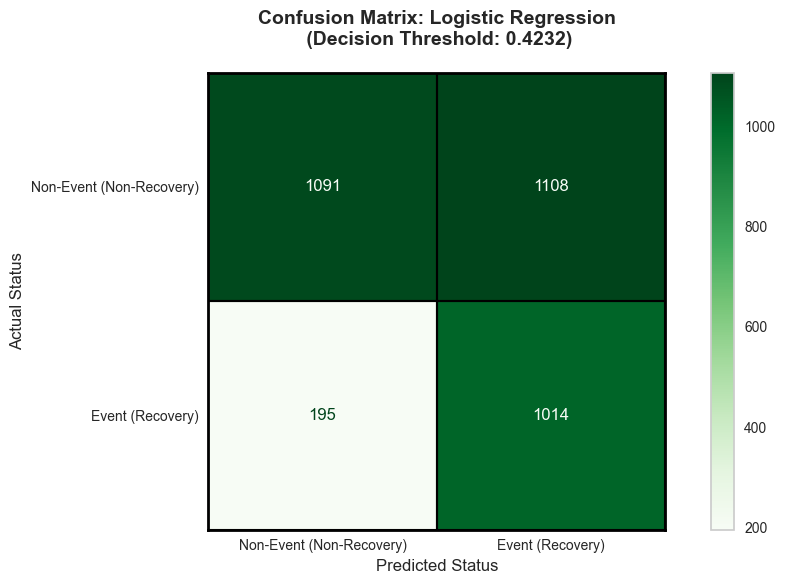

In [360]:
# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Compute confusion matrix
cm_lgd = confusion_matrix(lgd_Y_test, lgd_y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgd,
    display_labels=["Non-Event (Non-Recovery)", "Event (Recovery)"])

# Plot matrix
disp.plot(cmap='Greens', ax=ax, colorbar=True)

# Remove grid
ax.grid(False)

# Add borders around cells
for i in range(cm_lgd.shape[0]):
    for j in range(cm_lgd.shape[1]):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

# Add outer border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# Title and formatting
plt.title(f"Confusion Matrix: Logistic Regression\n (Decision Threshold: {lgd_optimal_threshold:.4f})",
    pad=20, fontsize=14, fontweight='bold')

plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)

ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

ROC-AUC Score: 0.7218
📊 Model Discrimination Performance:


,Metric,Value
0,ROC-AUC Score,0.72
1,Gini Index,0.44


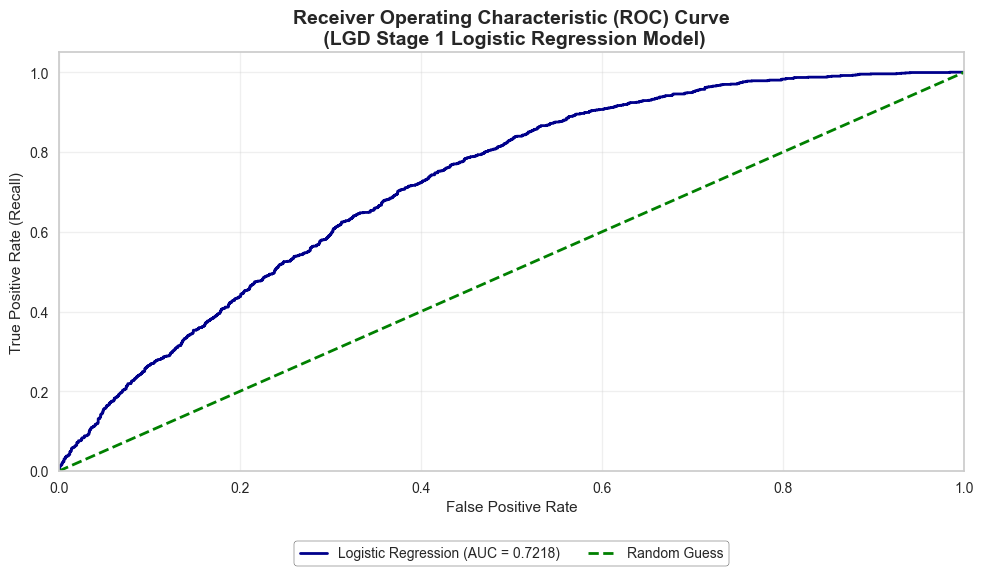

In [361]:
# ROC Curve Evaluation
# -----------------------------------------------------------------------------------------------
roc_lgd = roc_auc_score(lgd_Y_test, lgd_y_pred_proba)
print(f"ROC-AUC Score: {roc_lgd:.4f}")

# Derive the Gini Coefficient
gini_lgd = (2 * roc_lgd) - 1

# Create a dictionary for the metrics
cw_metrics_data = {
    "Metric": ["ROC-AUC Score", "Gini Index"],
    "Value": [round(roc_lgd, 4), round(gini_lgd, 4)]}

# Convert to a DataFrame for clean visualization
cw_metrics_df = pd.DataFrame(cw_metrics_data)

# Use display() to render the table nicely
print("📊 Model Discrimination Performance:")
display(cw_metrics_df)


# Calculate ROC curve coordinates
lgd_false_positive_rate, lgd_true_positive_rate, lgd_roc_thresholds = roc_curve(lgd_Y_test, lgd_y_pred_proba)

# Visualize ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(lgd_false_positive_rate, lgd_true_positive_rate, color="darkblue", linewidth=2, label=f"Logistic Regression (AUC = {roc_lgd:.4f})")

# Random Guess Reference Line
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")

# Format
plt.title("Receiver Operating Characteristic (ROC) Curve\n (LGD Stage 1 Logistic Regression Model)", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

In [362]:
# Create prediction results dataframe
lgd_predictions_df = pd.DataFrame({
    'Actual': lgd_Y_test.values,
    'Predicted': lgd_y_pred,
    'Predicted_Probability': lgd_y_pred_proba
})

# Flag whether prediction is correct
lgd_predictions_df['Correct_Prediction'] = (lgd_predictions_df['Actual'] == lgd_predictions_df['Predicted'])

# Round probabilities for readability
lgd_predictions_df['Predicted_Probability'] = (lgd_predictions_df['Predicted_Probability'].round(4))

# Calculate accuracy ratio
lgd_predictions_df['Correct_Prediction'] = (lgd_predictions_df['Actual'] == lgd_predictions_df['Predicted']).astype(int)
accuracy_ratio = lgd_predictions_df['Correct_Prediction'].mean()


# Display first 20 observations
print(f"Accuracy Ratio: {accuracy_ratio:.4%}")
display(lgd_predictions_df.head(20))

Accuracy Ratio: 61.7664%


,Actual,Predicted,Predicted_Probability,Correct_Prediction
0,1.00,1,0.63,1
1,1.00,1,0.48,1
2,1.00,1,0.75,1
3,0.00,1,0.58,0
4,0.00,0,0.25,1
5,0.00,0,0.41,1
6,0.00,1,0.59,0
7,0.00,0,0.19,1
8,0.00,0,0.15,1
9,0.00,0,0.22,1


In [363]:
# Get column names as a list
cols_stage1 = lgd_X_test.columns.tolist()

# Determine number of rows needed
nrows_stage1 = (len(cols_stage1) + 2) // 4

# Pad the list so length is a multiple of 4
padded = cols_stage1  + [''] * (nrows_stage1 * 4 - len(cols_stage1))

# Reshape into 4 columns (row by row)
reshaped = np.array(padded).reshape(nrows_stage1, 4)

# Create DataFrame with 4 columns
columns_df = pd.DataFrame(reshaped, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])
display(columns_df)

,Column 1,Column 2,Column 3,Column 4
0,funded_amnt,installment,total_acc,total_rev_hi_lim
1,open_acc,revol_util,mths_since_issue_d,all_util
2,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate
3,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc
4,inq_last_6mths,dti,emp_length,term_ 60 months
5,grade_B,grade_C,grade_D,grade_E
6,grade_F,grade_G,home_ownership_OTHER,home_ownership_OWN
7,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_Car financing
8,purpose_Credit card refinancing,purpose_Debt consolidation,purpose_Green loan,purpose_Home buying
9,purpose_Home improvement,purpose_Major purchase,purpose_Medical expenses,purpose_Moving and relocation


## The Regression Stage (Linear Regression)

After the classification stage identifies loans likely to experience partial recovery or loss, the second stage estimates the magnitude of recovery expected for those accounts. Since recovery outcomes are continuous values ranging between 0% and 100%, a regression model is applied to predict the recovery severity more precisely.

The objective is to quantify how much exposure is expected to be recovered after default, which directly supports the estimation of Loss Given Default (LGD):

$$LGD=1−Recovery\ Rate$$

How to interpret the output:
The model output is a continuous recovery estimate (e.g., 0.62). A higher predicted value indicates stronger expected recovery and therefore lower LGD, whereas a lower predicted value implies weaker recovery potential and higher expected loss severity. These estimates are subsequently integrated into the broader credit risk framework alongside PD and EAD for Expected Loss calculation.

In [364]:
# Stage 2 LGD model (Linear Regression for positive recoveries only)
train_recovery = train_defaults[train_defaults['recovery_rate'] > 0].copy()
test_recovery = test_defaults[test_defaults['recovery_rate'] > 0].copy()
print(f"Train positive recoveries: {train_recovery.shape[0]}")
print(f"Test positive recoveries : {test_recovery.shape[0]}")

Train positive recoveries: 5039
Test positive recoveries : 1209


In [365]:
# Isolate target variable
y_train_stage2 = train_recovery['recovery_rate']
y_test_stage2 = test_recovery['recovery_rate']

In [366]:
# Temporarily combine training and testing datasets to ensure consistent one-hot encoded columns are created across both splits
all_data_stage2 = pd.concat([train_recovery, test_recovery], axis=0, keys=['train', 'test'])

# Remove target and leakage variables from feature matrices
columns_to_drop = ['target','recovery_rate_0_1', 'recovery_rate', 'CCF']
X_all_stage2 = all_data_stage2.drop(columns=columns_to_drop, errors='ignore')

# Identify and scale numerical columns
numerical_columns_stage2 = X_all_stage2.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_all_stage2[numerical_columns_stage2] = scaler.fit_transform(X_all_stage2[numerical_columns_stage2])

# Apply one-hot encoding to categorical variables
X_all_stage2_encoded = pd.get_dummies(X_all_stage2, drop_first=True)

# Re-inspect the information about the dataset
X_all_stage2_encoded.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6248 entries, ('train', np.int64(43)) to ('test', np.int64(49827))
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   funded_amnt                          6248 non-null   float64
 1   installment                          6248 non-null   float64
 2   total_acc                            6248 non-null   float64
 3   total_rev_hi_lim                     6248 non-null   float64
 4   open_acc                             6248 non-null   float64
 5   revol_util                           6248 non-null   float64
 6   mths_since_issue_d                   6248 non-null   float64
 7   all_util                             6248 non-null   float64
 8   fico_mean                            6248 non-null   float64
 9   pub_rec_bankruptcies                 6248 non-null   float64
 10  pub_rec                              6248 non-null   

In [367]:
# Get column names as a list
cols_stage2 = X_all_stage2_encoded.columns.tolist()

# Determine number of rows needed
nrows_stage2 = (len(cols_stage2) + 2) // 4

# Pad the list so length is a multiple of 4
padded = cols_stage2  + [''] * (nrows_stage2 * 4 - len(cols_stage2))

# Reshape into 4 columns (row by row)
reshaped = np.array(padded).reshape(nrows_stage2, 4)

# Create DataFrame with 4 columns
columns_df = pd.DataFrame(reshaped, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])
display(columns_df)

,Column 1,Column 2,Column 3,Column 4
0,funded_amnt,installment,total_acc,total_rev_hi_lim
1,open_acc,revol_util,mths_since_issue_d,all_util
2,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate
3,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc
4,inq_last_6mths,dti,emp_length,term_ 60 months
5,grade_B,grade_C,grade_D,grade_E
6,grade_F,grade_G,sub_grade_A2,sub_grade_A3
7,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2
8,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1
9,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5


In [368]:
# Drop all sub_grade dummy variables automatically
extra_columns_to_drop = [col for col in X_all_stage2_encoded.columns if col.startswith('sub_grade_')]
X_all_stage2_encoded = X_all_stage2_encoded.drop(columns=extra_columns_to_drop, errors='ignore')

In [369]:
# Get column names as a list
cols_stage2 = X_all_stage2_encoded.columns.tolist()

# Determine number of rows needed
nrows_stage2 = (len(cols_stage2) + 2) // 4

# Pad the list so length is a multiple of 4
padded = cols_stage2  + [''] * (nrows_stage2 * 4 - len(cols_stage2))

# Reshape into 4 columns (row by row)
reshaped = np.array(padded).reshape(nrows_stage2, 4)

# Create DataFrame with 4 columns
columns_df = pd.DataFrame(reshaped, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])
display(columns_df)

,Column 1,Column 2,Column 3,Column 4
0,funded_amnt,installment,total_acc,total_rev_hi_lim
1,open_acc,revol_util,mths_since_issue_d,all_util
2,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate
3,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc
4,inq_last_6mths,dti,emp_length,term_ 60 months
5,grade_B,grade_C,grade_D,grade_E
6,grade_F,grade_G,home_ownership_OTHER,home_ownership_OWN
7,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_Car financing
8,purpose_Credit card refinancing,purpose_Debt consolidation,purpose_Green loan,purpose_Home buying
9,purpose_Home improvement,purpose_Major purchase,purpose_Medical expenses,purpose_Moving and relocation


In [370]:
# Restore train-test split
lgd_stage2_X_train = X_all_stage2_encoded.xs('train')
lgd_stage2_X_test = X_all_stage2_encoded.xs('test')

# Target variable
lgd_stage2_Y_train = y_train_stage2.copy()
lgd_stage2_Y_test = y_test_stage2.copy()

# Final check for shapes and column consistency
print(lgd_stage2_X_train.shape)
print(lgd_stage2_X_test.shape)
print(f" Train shapes: {lgd_stage2_X_train.shape} | Test shapes: {lgd_stage2_X_test.shape}")

(5039, 44)
(1209, 44)
 Train shapes: (5039, 44) | Test shapes: (1209, 44)


In [371]:
# ===============================================================================================
# Stage 2 LGD Model: Recovery Rate Prediction
# Compare Ordinary Least Squares (OLS) and Weighted OLS
# ===============================================================================================

# Fit standard OLS model
# -----------------------------------------------------------------------------------------------
linear_lgd = LinearRegression()
linear_lgd.fit(lgd_stage2_X_train, lgd_stage2_Y_train)

# Fit weighted OLS model
# -----------------------------------------------------------------------------------------------
n_bins = 10
binned = pd.cut(lgd_stage2_Y_train, bins=n_bins, labels=False)

# Assign larger weights to observations from less populated bins
weights = 1.0 / np.bincount(binned)[binned]

linear_lgd_weighted = LinearRegression()
linear_lgd_weighted.fit(lgd_stage2_X_train, lgd_stage2_Y_train, sample_weight=weights)

# Generate predictions
# -----------------------------------------------------------------------------------------------
pred_ols = linear_lgd.predict(lgd_stage2_X_test)
pred_wls = linear_lgd_weighted.predict(lgd_stage2_X_test)

# Recovery rates must remain within [0,1]
pred_ols = np.clip(pred_ols, 0, 1)
pred_wls = np.clip(pred_wls, 0, 1)

# Evaluate model performance
# -----------------------------------------------------------------------------------------------
mae_ols = mean_absolute_error(lgd_stage2_Y_test, pred_ols)
mse_ols = mean_squared_error(lgd_stage2_Y_test, pred_ols)
rmse_ols = np.sqrt(mse_ols)
r2_ols = r2_score(lgd_stage2_Y_test, pred_ols)

mae_wls = mean_absolute_error(lgd_stage2_Y_test, pred_wls)
mse_wls = mean_squared_error(lgd_stage2_Y_test, pred_wls)
rmse_wls = np.sqrt(mse_wls)
r2_wls = r2_score(lgd_stage2_Y_test, pred_wls)

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['OLS', 'Weighted OLS'],
    'MAE': [mae_ols, mae_wls],
    'MSE': [mse_ols, mse_wls],
    'RMSE': [rmse_ols, rmse_wls],
    'R2': [r2_ols, r2_wls]})

# Round results for presentation
comparison = comparison.round(4)

# Identify best-performing model based on RMSE
best_model = comparison.loc[comparison['RMSE'].idxmin(), 'Model']
print(f"Best model based on RMSE: {best_model}")
display(comparison)

Best model based on RMSE: OLS


,Model,MAE,MSE,RMSE,R2
0,OLS,0.03,0.00,0.05,0.02
1,Weighted OLS,0.27,0.10,0.32,-33.29


In [372]:
# Calculate residuals (OLS vs Weighted OLS)
residuals_ols = lgd_stage2_Y_test - pred_ols
residuals_wls = lgd_stage2_Y_test - pred_wls

# Residual Summary Statistics
residual_summary = pd.DataFrame({
    'Model': ['OLS', 'Weighted OLS'],
    'Residual Mean': [residuals_ols.mean(), residuals_wls.mean()],
    'Residual Std': [residuals_ols.std(), residuals_wls.std()],
    'Min Residual': [residuals_ols.min(), residuals_wls.min()],
    'Max Residual': [residuals_ols.max(), residuals_wls.max()]})

print("Residual Summary Statistics")
display(residual_summary)

Residual Summary Statistics


,Model,Residual Mean,Residual Std,Min Residual,Max Residual
0,OLS,-0.00,0.05,-0.12,0.72
1,Weighted OLS,-0.26,0.19,-0.93,0.42


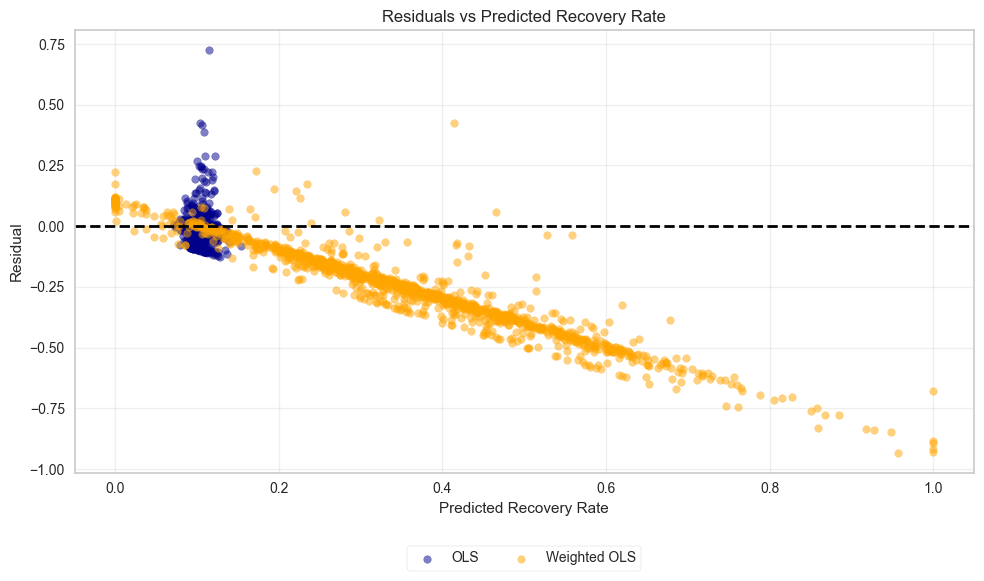

In [373]:
# Residuals vs Predicted Recovery Rate
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(pred_ols, residuals_ols, s=30, alpha=0.5, label='OLS', color='darkblue')
plt.scatter(pred_wls, residuals_wls, s=30, alpha=0.5, label='Weighted OLS', color='orange')
plt.axhline(y=0, linestyle='--', linewidth=2, color='black')
plt.xlabel('Predicted Recovery Rate')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Recovery Rate')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

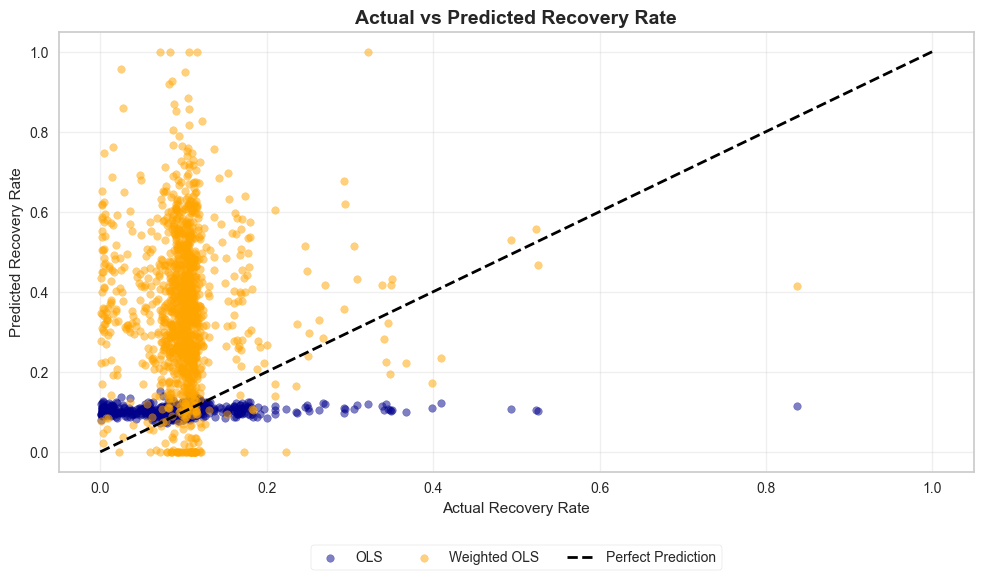

In [374]:
# Actual vs Predicted Recovery Rate
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(lgd_stage2_Y_test, pred_ols, s=30, alpha=0.5, label='OLS', color='darkblue')
plt.scatter(lgd_stage2_Y_test, pred_wls, s=30, alpha=0.5, label='Weighted OLS', color='orange')

# Perfect prediction line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='black', label='Perfect Prediction')
plt.xlabel('Actual Recovery Rate')
plt.ylabel('Predicted Recovery Rate')
plt.title('Actual vs Predicted Recovery Rate', fontweight='bold', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

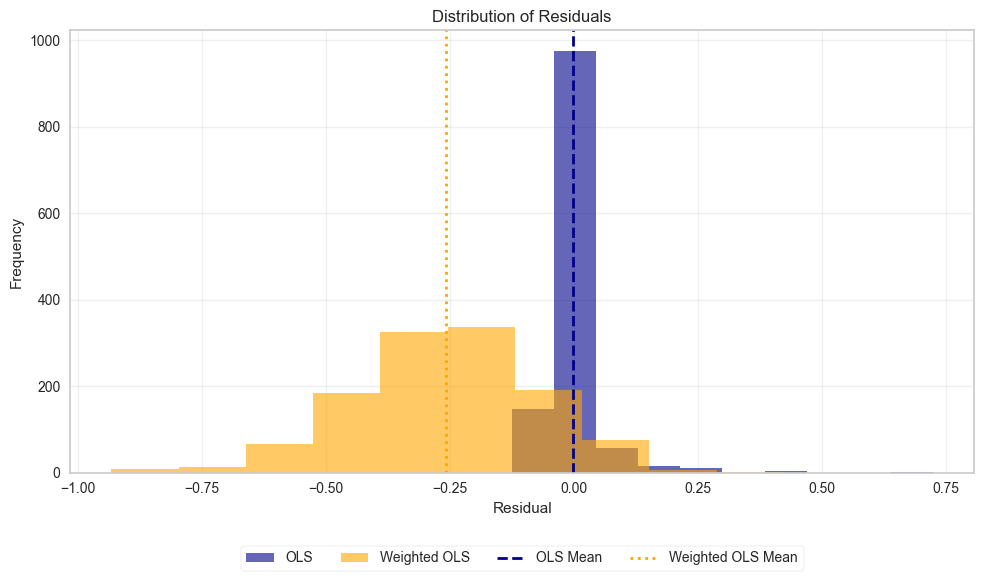

In [375]:
# Residual Distribution
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(residuals_ols, bins=10, alpha=0.6, label='OLS', color='darkblue')
plt.hist(residuals_wls, bins=10, alpha=0.6, label='Weighted OLS', color='orange')
plt.axvline(residuals_ols.mean(), linestyle='--', linewidth=2, label='OLS Mean', color='darkblue')
plt.axvline(residuals_wls.mean(), linestyle=':', linewidth=2, label='Weighted OLS Mean', color='orange')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [376]:
# Create a dataframe of OLS coefficients
coef_stage2 = pd.DataFrame({
    'Variable': lgd_stage2_X_train.columns,
    'Coefficient': linear_lgd.coef_})

# Calculate absolute coefficient values for ranking
coef_stage2['Absolute Coefficient'] = coef_stage2['Coefficient'].abs()

# Classify the direction of the relationship
coef_stage2['Effect on Recovery Rate'] = np.where(coef_stage2['Coefficient'] > 0, 'Positive', 'Negative')
coef_stage2 = coef_stage2.sort_values(by='Absolute Coefficient', ascending=False)
coef_stage2 = coef_stage2.reset_index(drop=True)

# Display top 20 most influential variables
display(coef_stage2.head(20))

,Variable,Coefficient,Absolute Coefficient,Effect on Recovery Rate
0,purpose_Major purchase,0.02,0.02,Positive
1,purpose_Vacation,0.02,0.02,Positive
2,home_ownership_OTHER,-0.01,0.01,Negative
3,purpose_Other,0.01,0.01,Positive
4,purpose_Car financing,0.01,0.01,Positive
5,purpose_Moving and relocation,0.01,0.01,Positive
6,purpose_Home improvement,0.01,0.01,Positive
7,purpose_Debt consolidation,0.01,0.01,Positive
8,grade_F,-0.01,0.01,Negative
9,purpose_Medical expenses,0.01,0.01,Positive


In [377]:
# Actual vs Predicted Recovery Rate
# -----------------------------------------------------------------------------------------------
results_stage2 = pd.DataFrame({
    'Actual_Recovery_Rate': lgd_stage2_Y_test.values,
    'Predicted_Recovery_Rate': pred_ols})

# 2. Add directional and absolute error columns (in percentage points for readability)
# -----------------------------------------------------------------------------------------------
results_stage2['Raw_Error'] = results_stage2['Actual_Recovery_Rate'] - results_stage2['Predicted_Recovery_Rate']
results_stage2['Absolute_Error'] = results_stage2['Raw_Error'].abs()

print("STAGE 2 RECOVERY RATE PREDICTIONS (FIRST 20 OBSERVATIONS)")
print("-" * 100)
display(results_stage2.head(20).style.format({
        'Actual_Recovery_Rate': '{:.2%}',
        'Predicted_Recovery_Rate': '{:.2%}',
        'Raw_Error': '{:+.2%}',
        'Absolute_Error': '{:.2%}'}))

STAGE 2 RECOVERY RATE PREDICTIONS (FIRST 20 OBSERVATIONS)
----------------------------------------------------------------------------------------------------


,Actual_Recovery_Rate,Predicted_Recovery_Rate,Raw_Error,Absolute_Error
0,4.34%,9.42%,-5.08%,5.08%
1,4.25%,9.62%,-5.36%,5.36%
2,18.94%,11.19%,+7.76%,7.76%
3,9.15%,9.62%,-0.47%,0.47%
4,15.86%,10.84%,+5.02%,5.02%
5,9.16%,9.19%,-0.03%,0.03%
6,10.34%,10.74%,-0.40%,0.40%
7,11.25%,11.18%,+0.07%,0.07%
8,10.94%,10.52%,+0.42%,0.42%
9,11.49%,12.52%,-1.02%,1.02%


## LGD computation

**Final LGD estimation: Combining stage 1 and stage 2**

Loss Given Default (LGD) is calculated using a classic two-stage conditional approach:
- Stage 1 (Classification): Predicts the probability that an account yields ANY recovery. Target: recovery_rate ≠ 0 (Binary: 0 or 1)
- Stage 2 (Regression):     Predicts the specific proportion recovered, GIVEN that a recovery occurs. Trained strictly on the non-zero recovery subset. Target: recovery_rate ∈ [0, 1] (Continuous fraction)

By multiplying the probability of recovery by the expected amount conditional on recovery, we mathematically account for the zero-inflation (massive spike of $0 accounts) typical in credit default data without biasing the continuous regression line.

---

**📊 Final Expected LGD Calculation**

The final Loss Given Default (LGD) is computed by combining the outputs of the Stage 1 (Classification) and Stage 2 (Regression) models using a conditional probability framework.

**1. Expected Recovery Rate (RR) formula**

The overall expected recovery rate is the probability of recovering *any* funds (Stage 1) scaled by the expected amount recovered given a non-zero event (Stage 2):

$$\text{Expected Recovery Rate} = P(\text{Recovery} > 0 \mid \text{Stage 1}) \times \text{Predicted Recovery Rate}_{\text{Stage 2}}$$

**2. Expected Loss Given Default (LGD) formula**
The final LGD represents the economic loss percentage on the outstanding Balance at Default after accounting for all realized recoveries:

$$\text{Final Expected LGD} = 1 - \text{Expected Recovery Rate}$$



| Component | Model Source | Target Output Type | Definition |
| :--- | :--- | :--- | :--- |
| **$P(\text{Recovery} > 0)$** | Stage 1 (Logistic Regression / Classifier) | Probability (`0.0` to `1.0`) | Probability that liquidators recover at least some funds. |
| **$\text{Predicted RR}_{\text{Stage 2}}$** | Stage 2 (Regressor / Fractional Logit) | Continuous Fraction (`0.0` to `1.0`) | Expected recovery amount, given the account didn't result in a 100% total loss. |
| **$\text{Final Expected LGD}$** | Combined Pipeline Output | Loss Percentage (`0.0` to `1.0`) | Percentage of the exposure expected to be permanently written off. |


- Stage 1 (`lgd_y_pred_proba`) outputs predictions for the entire test set to determine the probability that an account will have any recovery.
- Stage 2 (`pred_ols`) is evaluated only on the subset of accounts that actually experienced a positive recovery

In [378]:
# Generate Stage 2 Recovery Rate predictions on the FULL test set (all defaults)
# -----------------------------------------------------------------------------------------------
pred_ols_raw = linear_lgd.predict(lgd_X_test)
pred_ols_full = np.clip(pred_ols_raw, 0.0, 1.0)

# Calculate expected recovery rate using Stage 1 probabilities (NOT binary predictions) and estimate LGD
# -----------------------------------------------------------------------------------------------
expected_recovery_rate = lgd_y_pred_proba * pred_ols_full
predicted_lgd = 1.0 - expected_recovery_rate

# 3. Build DataFrame
# -----------------------------------------------------------------------------------------------
results_lgd = pd.DataFrame({
    'Probability_of_Recovery (Stage 1)': lgd_y_pred_proba,
    'Conditional_Recovery_Rate (Stage 2)': pred_ols_full,
    'Actual_Recovery_Rate': test_defaults['recovery_rate'].values,
    'Expected_Recovery_Rate': expected_recovery_rate,
    'Actual_LGD': 1.0 - test_defaults['recovery_rate'].values,
    'Predicted_LGD': predicted_lgd})

# Calculate Residuals (Actual minus Predicted)
# -----------------------------------------------------------------------------------------------
# Positive residual = Model Underestimated Loss (Actual Loss > Predicted Loss)
# Negative residual = Model Overestimated Loss (Actual Loss < Predicted Loss)
results_lgd['LGD_Residual'] = results_lgd['Actual_LGD'] - results_lgd['Predicted_LGD']
results_lgd['Absolute_Error'] = results_lgd['LGD_Residual'].abs()

# Evaluate model performance
# -----------------------------------------------------------------------------------------------
mae = mean_absolute_error(results_lgd['Actual_LGD'], results_lgd['Predicted_LGD'])
mse = mean_squared_error(results_lgd['Actual_LGD'], results_lgd['Predicted_LGD'])
rmse = np.sqrt(mse)
r2 = r2_score(results_lgd['Actual_LGD'], results_lgd['Predicted_LGD'])

mean_actual_lgd = results_lgd['Actual_LGD'].mean()
mean_pred_lgd = results_lgd['Predicted_LGD'].mean()
model_bias = results_lgd['LGD_Residual'].mean() 
bias_direction = "Underpredicting Risk (Aggressive)" if model_bias > 0 else "Overpredicting Risk (Conservative)"

total_actual_lgd = results_lgd['Actual_LGD'].sum()
total_predicted_lgd = results_lgd['Predicted_LGD'].sum()
total_portfolio_delta = (total_actual_lgd - total_predicted_lgd)
pct_portfolio_delta = (total_portfolio_delta / total_actual_lgd)


metrics_summary = pd.DataFrame({
    'Metric': ['Mean Actual LGD', 'Mean Predicted LGD', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R² Coefficient of Determination','Systemic Bias (Mean Residual)'],
    'Value': [round(mean_actual_lgd, 4), round(mean_pred_lgd, 4), round(mae, 4), round(mse, 4), round(rmse, 4), round(r2, 4), round(model_bias, 4)]})

print("\n📈 OVERALL TWO-STAGE LGD MODEL PERFORMANCE")
print("-" * 100)
display(metrics_summary)

if model_bias > 0:
    bias_direction = "Underpredicting Risk (Aggressive)"
elif model_bias < 0:
    bias_direction = "Overpredicting Risk (Conservative)"
else:
    bias_direction = "Unbiased"
print(f"👉 Model Tendency: The model is currently {bias_direction} by {abs(model_bias):.2%} per account on average.\n")

if pct_portfolio_delta > 0:
    print(f"👉 Portfolio Impact: Total LGD is underestimated by {pct_portfolio_delta:.2%}.")
elif pct_portfolio_delta < 0:
    print(f"👉 Portfolio Impact: Total LGD is overestimated by {abs(pct_portfolio_delta):.2%}.")
else:
    print("👉 Portfolio Impact: Predicted and actual portfolio LGD are identical.")


📈 OVERALL TWO-STAGE LGD MODEL PERFORMANCE
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Mean Actual LGD,0.96
1,Mean Predicted LGD,0.95
2,Mean Absolute Error (MAE),0.05
3,Mean Squared Error (MSE),0.00
4,Root Mean Squared Error (RMSE),0.06
5,R² Coefficient of Determination,0.03
6,Systemic Bias (Mean Residual),0.01


👉 Model Tendency: The model is currently Underpredicting Risk (Aggressive) by 1.32% per account on average.

👉 Portfolio Impact: Total LGD is underestimated by 1.37%.


In [379]:
# Segmenting accounts based on their risk profile to spot business-level implications
total_accounts = len(results_lgd)
total_loss_accounts = (results_lgd['Predicted_LGD'] >= 0.95).sum()
high_recovery_accounts = (results_lgd['Expected_Recovery_Rate'] >= 0.50).sum()

print("\n📊 PORTFOLIO RISK PROFILE SUMMARY")
print("-" * 100)
print(f"• Total Defaulted Accounts Evaluated   : {total_accounts}")
print(f"• Mean Expected Portfolio LGD          : {results_lgd['Predicted_LGD'].mean():.2%}")
print(f"• Mean Expected Portfolio Recovery     : {results_lgd['Expected_Recovery_Rate'].mean():.2%}")
print(f"• Near-Total Loss Accounts (LGD ≥ 95%) : {total_loss_accounts} ({total_loss_accounts/total_accounts:.2%})")
print(f"• High Recovery Accounts (Rec ≥ 50%)   : {high_recovery_accounts} ({high_recovery_accounts/total_accounts:.2%})")

# Preview data
print("\n👀 PREDICTION SNAPSHOT (Sample Rows):")
print("-" * 100)
display(results_lgd.head(10))


📊 PORTFOLIO RISK PROFILE SUMMARY
----------------------------------------------------------------------------------------------------
• Total Defaulted Accounts Evaluated   : 3408
• Mean Expected Portfolio LGD          : 95.11%
• Mean Expected Portfolio Recovery     : 4.89%
• Near-Total Loss Accounts (LGD ≥ 95%) : 1688 (49.53%)
• High Recovery Accounts (Rec ≥ 50%)   : 0 (0.00%)

👀 PREDICTION SNAPSHOT (Sample Rows):
----------------------------------------------------------------------------------------------------


,Probability_of_Recovery (Stage 1),Conditional_Recovery_Rate (Stage 2),Actual_Recovery_Rate,Expected_Recovery_Rate,Actual_LGD,Predicted_LGD,LGD_Residual,Absolute_Error
0,0.63,0.09,0.04,0.06,0.96,0.94,0.02,0.02
1,0.48,0.10,0.04,0.05,0.96,0.95,0.00,0.00
2,0.75,0.11,0.19,0.08,0.81,0.92,-0.11,0.11
3,0.58,0.12,0.00,0.07,1.00,0.93,0.07,0.07
4,0.25,0.10,0.00,0.03,1.00,0.97,0.03,0.03
5,0.41,0.12,0.00,0.05,1.00,0.95,0.05,0.05
6,0.59,0.09,0.00,0.05,1.00,0.95,0.05,0.05
7,0.19,0.12,0.00,0.02,1.00,0.98,0.02,0.02
8,0.15,0.10,0.00,0.01,1.00,0.99,0.01,0.01
9,0.22,0.11,0.00,0.02,1.00,0.98,0.02,0.02


In [380]:
# Error distribution profile
# -----------------------------------------------------------------------------------------------
underestimated_mask = results_lgd['LGD_Residual'] > 0.05
overestimated_mask = results_lgd['LGD_Residual'] < -0.05
accurate_mask = results_lgd['Absolute_Error'] <= 0.05

total_obs = len(results_lgd)

error_profile = pd.DataFrame({
    'Prediction Segment': ['Accurate Predictions (Within ±5%)', 'Underestimated Losses (Actual > Pred + 5%)', 'Overestimated Losses (Actual < Pred - 5%)'],
    'Account Count': [accurate_mask.sum(), underestimated_mask.sum(), overestimated_mask.sum()],
    'Portfolio Share': [f"{accurate_mask.sum()/total_obs:.2%}", f"{underestimated_mask.sum()/total_obs:.2%}", f"{overestimated_mask.sum()/total_obs:.2%}"],
    'Average Absolute Error': [
        round(results_lgd.loc[accurate_mask, 'Absolute_Error'].mean(), 4),
        round(results_lgd.loc[underestimated_mask, 'Absolute_Error'].mean(), 4),
        round(results_lgd.loc[overestimated_mask, 'Absolute_Error'].mean(), 4)
    ]
})

print("📊 ERROR DISTRIBUTION PROFILE")
print("-" * 75)
display(error_profile)

📊 ERROR DISTRIBUTION PROFILE
---------------------------------------------------------------------------


,Prediction Segment,Account Count,Portfolio Share,Average Absolute Error
0,Accurate Predictions (Within ±5%),2092,61.38%,0.03
1,Underestimated Losses (Actual > Pred + 5%),896,26.29%,0.06
2,Overestimated Losses (Actual < Pred - 5%),420,12.32%,0.09


In [381]:
# Worst Predictions preview
# -----------------------------------------------------------------------------------------------
print("\n🚨 TARGETED INSPECTION: TOP 5 WORST PREDICTIONS (Largest Absolute Residuals)")
print("-" * 100)
worst_preds = results_lgd.sort_values(by='Absolute_Error', ascending=False).head(5)
display(worst_preds[['Actual_LGD', 'Predicted_LGD', 'LGD_Residual', 'Absolute_Error', 'Probability_of_Recovery (Stage 1)', 'Conditional_Recovery_Rate (Stage 2)']])


🚨 TARGETED INSPECTION: TOP 5 WORST PREDICTIONS (Largest Absolute Residuals)
----------------------------------------------------------------------------------------------------


,Actual_LGD,Predicted_LGD,LGD_Residual,Absolute_Error,Probability_of_Recovery (Stage 1),Conditional_Recovery_Rate (Stage 2)
508,0.16,0.93,-0.76,0.76,0.65,0.11
2667,0.47,0.95,-0.47,0.47,0.51,0.10
1303,0.48,0.95,-0.47,0.47,0.52,0.10
3093,0.51,0.94,-0.44,0.44,0.55,0.11
692,0.59,0.96,-0.37,0.37,0.37,0.12


## EAD Model

The Exposure at Default (EAD) model estimates the amount of exposure that remains outstanding at the time of default.

Following common credit risk modelling practice, EAD is estimated indirectly through the Credit Conversion Factor (CCF), which measures the proportion of the original exposure that is not recovered.

$$CCF = \frac{\text{Funded Amount} - \text{Recovered Principal}}{\text{Funded Amount}}$$

The estimated EAD is then calculated as:

$$EAD = CCF \times \text{Funded Amount}$$

A linear regression model is used to predict the CCF based on borrower and loan characteristics.

In [382]:
# Isolate target variable
ead_y_train = train_defaults['CCF']
ead_y_test = test_defaults['CCF']

In [383]:
# Temporarily combine training and testing datasets to ensure consistent one-hot encoded columns are created across both splits
all_data = pd.concat([train_defaults, test_defaults], axis=0, keys=['train', 'test'])

# Remove target and leakage variables from feature matrices
columns_to_drop = ['target','recovery_rate_0_1', 'recovery_rate', 'CCF']
ead_X = all_data.drop(columns=columns_to_drop, errors='ignore')

# Identify and scale numerical columns
numerical_columns = ead_X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
ead_X[numerical_columns] = scaler.fit_transform(ead_X[numerical_columns])

# Apply one-hot encoding to categorical variables
ead_X = pd.get_dummies(X_all, drop_first=True)

# Re-inspect the information about the dataset
ead_X.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 17041 entries, ('train', np.int64(0)) to ('test', np.int64(49988))
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   funded_amnt                          17041 non-null  float64
 1   installment                          17041 non-null  float64
 2   total_acc                            17041 non-null  float64
 3   total_rev_hi_lim                     17041 non-null  float64
 4   open_acc                             17041 non-null  float64
 5   revol_util                           17041 non-null  float64
 6   mths_since_issue_d                   17041 non-null  float64
 7   all_util                             17041 non-null  float64
 8   fico_mean                            17041 non-null  float64
 9   pub_rec_bankruptcies                 17041 non-null  float64
 10  pub_rec                              17041 non-null  

In [384]:
# Get column names as a list
cols_ead = ead_X.columns.tolist()

# Determine number of rows needed
nrows_ead = (len(cols_ead) + 2) // 4

# Pad the list so length is a multiple of 4
padded = cols_ead  + [''] * (nrows_ead * 4 - len(cols_ead))

# Reshape into 4 columns (row by row)
reshaped = np.array(padded).reshape(nrows_ead, 4)

# Create DataFrame with 4 columns
columns_df = pd.DataFrame(reshaped, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])
display(columns_df)

,Column 1,Column 2,Column 3,Column 4
0,funded_amnt,installment,total_acc,total_rev_hi_lim
1,open_acc,revol_util,mths_since_issue_d,all_util
2,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate
3,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc
4,inq_last_6mths,dti,emp_length,term_ 60 months
5,grade_B,grade_C,grade_D,grade_E
6,grade_F,grade_G,sub_grade_A2,sub_grade_A3
7,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2
8,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1
9,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5


In [385]:
# Drop all sub_grade dummy variables automatically
extra_columns_to_drop = [col for col in ead_X.columns if col.startswith('sub_grade_')]
ead_X_encoded = ead_X.drop(columns=extra_columns_to_drop, errors='ignore')

In [386]:
# Get column names as a list
cols_ead = ead_X_encoded.columns.tolist()

# Determine number of rows needed
nrows_ead = (len(cols_ead) + 2) // 4

# Pad the list so length is a multiple of 4
padded = cols_ead  + [''] * (nrows_ead * 4 - len(cols_ead))

# Reshape into 4 columns (row by row)
reshaped = np.array(padded).reshape(nrows_ead, 4)

# Create DataFrame with 4 columns
columns_df = pd.DataFrame(reshaped, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])
display(columns_df)

,Column 1,Column 2,Column 3,Column 4
0,funded_amnt,installment,total_acc,total_rev_hi_lim
1,open_acc,revol_util,mths_since_issue_d,all_util
2,fico_mean,pub_rec_bankruptcies,pub_rec,int_rate
3,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc
4,inq_last_6mths,dti,emp_length,term_ 60 months
5,grade_B,grade_C,grade_D,grade_E
6,grade_F,grade_G,home_ownership_OTHER,home_ownership_OWN
7,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_Car financing
8,purpose_Credit card refinancing,purpose_Debt consolidation,purpose_Green loan,purpose_Home buying
9,purpose_Home improvement,purpose_Major purchase,purpose_Medical expenses,purpose_Moving and relocation


In [387]:
# Split back into training and testing sets
ead_X_train = ead_X_encoded.xs('train')
ead_X_test = ead_X_encoded.xs('test')

# Redefine target variable
ead_y_train = ead_y_train.copy()
ead_y_test = ead_y_test.copy()

# Final check for shapes and column consistency
print(f" Train shapes: {ead_X_train.shape} | Test shapes: {ead_X_test.shape}")

 Train shapes: (13633, 44) | Test shapes: (3408, 44)


In [388]:
# Fit EAD Regression model
# -----------------------------------------------------------------------------------------------
linear_ead = LinearRegression()
linear_ead.fit(ead_X_train, ead_y_train)

# Predict Credit Conversion Factor (CCF)
# -----------------------------------------------------------------------------------------------
ead_pred = linear_ead.predict(ead_X_test)
ead_pred = np.clip(ead_pred, 0, 1)

In [389]:
# Evaluate EAD model performance (Mirrors the Two-Stage LGD evaluation structure)
# -----------------------------------------------------------------------------------------------
# Build Results DataFrame
results_ead = pd.DataFrame({
    'Actual_EAD': ead_y_test.values if hasattr(ead_y_test, 'values') else ead_y_test,
    'Predicted_EAD': ead_pred})

# Calculate Residuals (Actual minus Predicted)
# -----------------------------------------------------------------------------------------------
# Positive residual = Model Underestimated Exposure (Actual Balance > Predicted Balance)
# Negative residual = Model Overestimated Exposure (Actual Balance < Predicted Balance)
results_ead['EAD_Residual'] = results_ead['Actual_EAD'] - results_ead['Predicted_EAD']
results_ead['Absolute_Error'] = results_ead['EAD_Residual'].abs()

# Evaluate model performance metrics
# -----------------------------------------------------------------------------------------------
ead_mae = mean_absolute_error(results_ead['Actual_EAD'], results_ead['Predicted_EAD'])
ead_mse = mean_squared_error(results_ead['Actual_EAD'], results_ead['Predicted_EAD'])
ead_rmse = np.sqrt(ead_mse)
ead_r2 = r2_score(results_ead['Actual_EAD'], results_ead['Predicted_EAD'])

mean_actual_ead = results_ead['Actual_EAD'].mean()
mean_pred_ead = results_ead['Predicted_EAD'].mean()
ead_model_bias = results_ead['EAD_Residual'].mean() 

# Capital impact interpretation: positive bias means the bank under-reserved capital
ead_bias_direction = "Underpredicting Risk (Aggressive)" if ead_model_bias > 0 else "Overpredicting Risk (Conservative)"

# Residual = Actual Exposure minus Predicted Exposure
ead_residuals = ead_y_test - ead_pred
abs_errors = np.abs(ead_residuals)
total_actual_exposure = np.sum(ead_y_test)
total_predicted_exposure = np.sum(ead_pred)

# Systemic Model Bias (Mean Error)
# Positive = Underestimating portfolio risk (Dangerous/Aggressive)
# Negative = Overestimating portfolio risk (Conservative/Capital-Heavy)
mean_bias = np.mean(ead_residuals)
total_portfolio_delta = total_actual_exposure - total_predicted_exposure
pct_portfolio_delta = total_portfolio_delta / total_actual_exposure

bias_interpretation = ("Underpredicting Risk (Aggressive)" if mean_bias > 0 else "Overpredicting Risk (Conservative)")

# Compile metrics summary table
# -----------------------------------------------------------------------------------------------
ead_metrics_summary = pd.DataFrame({
    'Metric': [
        'Mean Actual EAD', 
        'Mean Predicted EAD', 
        'Mean Absolute Error (MAE)', 
        'Mean Squared Error (MSE)', 
        'Root Mean Squared Error (RMSE)', 
        'R² Coefficient of Determination',
        'Systemic Bias (Mean Residual)'],
    'Value': [
        round(mean_actual_ead, 4), 
        round(mean_pred_ead, 4), 
        round(ead_mae, 4), 
        round(ead_mse, 4), 
        round(ead_rmse, 4), 
        round(ead_r2, 4), 
        round(ead_model_bias, 4)]})

print("\n📈 OVERALL EAD MODEL PERFORMANCE")
print("-" * 100)
display(ead_metrics_summary)
print(f"👉 Model Tendency: The model is currently {ead_bias_direction} by {abs(ead_model_bias):.2f} per account on average.\n")
print(f"👉 Total Dollar Variance: The model differs from actual exposure by ${abs(total_portfolio_delta):,.2f}.\n")



📈 OVERALL EAD MODEL PERFORMANCE
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Mean Actual EAD,0.82
1,Mean Predicted EAD,0.82
2,Mean Absolute Error (MAE),0.08
3,Mean Squared Error (MSE),0.01
4,Root Mean Squared Error (RMSE),0.12
5,R² Coefficient of Determination,0.35
6,Systemic Bias (Mean Residual),-0.00


👉 Model Tendency: The model is currently Overpredicting Risk (Conservative) by 0.00 per account on average.

👉 Total Dollar Variance: The model differs from actual exposure by $9.60.



In [390]:
# Error distribution profile (Risk Tiering)
# -----------------------------------------------------------------------------------------------
total_accounts = len(ead_y_test)
accurate_mask = abs_errors <= 1000       # Adjust dollar threshold based on asset size
under_mask = ead_residuals > 1000
over_mask = ead_residuals < -1000

error_distribution = pd.DataFrame({
    'Prediction Segment': [
        'Accurate Estimates (Within ±$1,000)', 
        'Underpredicted Exposure (Actual > Pred by > $1,000)', 
        'Overpredicted Exposure (Actual < Pred by > $1,000)'],
    'Account Count': [accurate_mask.sum(), under_mask.sum(), over_mask.sum()],
    'Portfolio Share (%)': [
        f"{accurate_mask.sum()/total_accounts:.2%}", 
        f"{under_mask.sum()/total_accounts:.2%}", 
        f"{over_mask.sum()/total_accounts:.2%}"],
    'Avg Absolute Error ($)': [
        f"${abs_errors[accurate_mask].mean():,.2f}" if accurate_mask.any() else "$0.00",
        f"${abs_errors[under_mask].mean():,.2f}" if under_mask.any() else "$0.00",
        f"${abs_errors[over_mask].mean():,.2f}" if over_mask.any() else "$0.00"]})

print("📊 PORTFOLIO ERROR DISTRIBUTION PROFILE")
print("-" * 100)
display(error_distribution)

📊 PORTFOLIO ERROR DISTRIBUTION PROFILE
----------------------------------------------------------------------------------------------------


,Prediction Segment,Account Count,Portfolio Share (%),Avg Absolute Error ($)
0,"Accurate Estimates (Within ±$1,000)",3408,100.00%,$0.08
1,"Underpredicted Exposure (Actual > Pred by > $1,000)",0,0.00%,$0.00
2,"Overpredicted Exposure (Actual < Pred by > $1,000)",0,0.00%,$0.00


In [391]:
# Worst Predictions preview
# -----------------------------------------------------------------------------------------------
print("\n🚨 RISK AUDIT: TOP 5 LARGEST PREDICTION OUTLIERS")
print("-" * 80)

audit_df = pd.DataFrame({
    'Actual_EAD': ead_y_test,
    'Predicted_EAD': ead_pred,
    'Residual (Actual - Pred)': ead_residuals,
    'Absolute_Error': abs_errors
}).sort_values(by='Absolute_Error', ascending=False).head(5)

display(audit_df.round(2))


🚨 RISK AUDIT: TOP 5 LARGEST PREDICTION OUTLIERS
--------------------------------------------------------------------------------


,Actual_EAD,Predicted_EAD,Residual (Actual - Pred),Absolute_Error
38677,0.00,0.95,-0.95,0.95
31843,0.00,0.90,-0.90,0.90
16917,0.02,0.85,-0.83,0.83
45757,0.10,0.93,-0.82,0.82
35381,0.11,0.88,-0.77,0.77


In [392]:
# EAD profile summary
# -----------------------------------------------------------------------------------------------
funded_amount_test = test_defaults.loc[ead_X_test.index, 'funded_amnt']

# Calculate Exposure at Default
predicted_ead = (ead_pred * funded_amount_test)
actual_ead = (ead_y_test * funded_amount_test)
results_ead = pd.DataFrame({
    'Actual_CCF': ead_y_test,
    'Predicted_CCF': ead_pred,
    'Funded_Amount': funded_amount_test,
    'Actual_EAD': actual_ead,
    'Predicted_EAD': predicted_ead})

display(results_ead.head())

,Actual_CCF,Predicted_CCF,Funded_Amount,Actual_EAD,Predicted_EAD
26,0.74,0.70,17400.00,12935.70,12168.33
34,0.75,0.71,1800.00,1343.57,1279.90
38,0.95,0.85,24000.00,22680.46,20280.59
39,0.71,0.85,4350.00,3106.00,3718.91
42,0.79,0.76,16800.00,13294.37,12738.20


# Load Saved PD model

In [393]:
import pickle

# Define paths and load model artifacts
# -----------------------------------------------------------------------------------------------
model_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"
model_filename = "credit_risk_pd_model.pkl"
full_model_path = os.path.join(model_directory, model_filename)

try:
    with open(full_model_path, "rb") as file:
        loaded_pd_data = pickle.load(file)
    print(f"✅ Successfully loaded PD artifacts from:\n{full_model_path}")
    # View what had been saved in the model
    print(loaded_pd_data.keys())

except FileNotFoundError:
    print(f"❌ Could not find file:\n{full_model_path}")

except Exception as e:
    print(f"❌ Error loading PD model: {e}")

✅ Successfully loaded PD artifacts from:
C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\credit_risk_pd_model.pkl
dict_keys(['model', 'calibration_model', 'optimal_threshold', 'factor', 'offset', 'target_score', 'target_odds', 'pdo', 'min_score', 'max_score', 'feature_names', 'roc_auc', 'f1_score', 'recall', 'precision'])


In [394]:
# Load the Test dataset PD predictions
# -----------------------------------------------------------------------------------------------
target_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"
pd_export_path = os.path.join(target_directory, "pd_predictions_full_test.csv")

try:
    full_pd_predictions = pd.read_csv(pd_export_path, index_col=0)
    print(f"✅ Successfully loaded Test dataset PD predictions from:\n{pd_export_path}")
    print(f"📊 Records Loaded: {len(full_pd_predictions):,}")
    print(f"📋 Portfolio Columns: {full_pd_predictions.columns.tolist()}")

except FileNotFoundError:
    print(f"❌ PD prediction file not found:\n{pd_export_path}")

except Exception as e:
    print(f"❌ Error loading PD predictions: {e}")

✅ Successfully loaded Test dataset PD predictions from:
C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\pd_predictions_full_test.csv
📊 Records Loaded: 50,000
📋 Portfolio Columns: ['Probability_of_Default (PD)', 'Actual_Default_Status', 'funded_amnt', 'int_rate', 'fico_mean', 'term']


In [395]:
# Total funded amount in test portfolio
# -----------------------------------------------------------------------------------------------
total_funded_volume = full_pd_predictions['funded_amnt'].sum()
total_accounts = len(full_pd_predictions)

# Align PD predictions for test set with LGD/EAD test set population
# -----------------------------------------------------------------------------------------------
matching_pd_probabilities = (full_pd_predictions.loc[test_defaults.index, 'Probability_of_Default (PD)'].values)
avg_fico_score = (full_pd_predictions.loc[test_defaults.index, 'fico_mean'].mean())

# Expected Loss computation

In [396]:
results_el = pd.DataFrame({
    'Probability_of_Default (PD)': matching_pd_probabilities,
    'Predicted_LGD': predicted_lgd,  
    'Predicted_EAD': predicted_ead,
    'Loan_Term': full_pd_predictions['term'],
    'Original_Amount': full_pd_predictions['funded_amnt']
}, index=test_defaults.index)

# Compute Expected Loss (EL)
results_el['Expected_Loss (EL)'] = (results_el['Probability_of_Default (PD)'] * results_el['Predicted_LGD'] * results_el['Predicted_EAD'])
print("=" * 100)
print(f"✅ Success! Aligned shapes from 50,000 down to {len(results_el)} defaulted accounts.")
print("=" * 100)
display(results_el.head(10))

✅ Success! Aligned shapes from 50,000 down to 3408 defaulted accounts.


,Probability_of_Default (PD),Predicted_LGD,Predicted_EAD,Loan_Term,Original_Amount,Expected_Loss (EL)
26,0.75,0.94,12168.33,36 months,17400.00,8540.86
34,0.42,0.95,1279.90,36 months,1800.00,508.27
38,0.81,0.92,20280.59,60 months,24000.00,15066.73
39,0.83,0.93,3718.91,36 months,4350.00,2870.27
42,0.15,0.97,12738.20,36 months,16800.00,1834.77
43,0.69,0.95,1557.52,36 months,2000.00,1026.59
79,0.86,0.95,25016.90,36 months,35000.00,20431.91
103,0.63,0.98,5756.63,36 months,6100.00,3531.84
115,0.50,0.99,22753.43,36 months,25000.00,11158.74
134,0.37,0.98,10225.24,36 months,12000.00,3642.86


In [397]:
# Summary Metrics
total_portfolio_ead = results_el['Predicted_EAD'].sum()
total_portfolio_el = results_el['Expected_Loss (EL)'].sum()
portfolio_loss_rate = total_portfolio_el / total_portfolio_ead if total_portfolio_ead > 0 else 0
weighted_lgd = (results_el['Predicted_LGD'] * results_el['Predicted_EAD']).sum() / total_portfolio_ead
loss_rate_period = (results_el['Expected_Loss (EL)'].sum() / total_funded_volume)*100

total_default_accounts = len(results_el['Expected_Loss (EL)'])
top_10_pct_threshold = (results_el['Expected_Loss (EL)'].quantile(0.90))
high_risk_accounts = (results_el['Expected_Loss (EL)'] >= top_10_pct_threshold)
high_risk_el = (results_el.loc[high_risk_accounts, 'Expected_Loss (EL)'].sum())
high_risk_pct = (high_risk_el / total_portfolio_el)

# Account-Level Statistical Summary for Expected Loss (EL)
el_desc = results_el['Expected_Loss (EL)'].describe()
print("ACCOUNT-LEVEL EXPECTED LOSS (EL) STATISTICS")
print("-" * 100)
print(f"• Mean Account Expected Loss         : ${el_desc['mean']:,.2f}")
print(f"• Standard Deviation                 : ${el_desc['std']:,.2f}")
print(f"• Minimum Expected Loss              : ${el_desc['min']:,.2f}")
print(f"• 25th Percentile (Q1)               : ${el_desc['25%']:,.2f}")
print(f"• Median Expected Loss (50%)         : ${el_desc['50%']:,.2f}")
print(f"• 75th Percentile (Q3)               : ${el_desc['75%']:,.2f}")
print(f"• Maximum Account Expected Loss      : ${el_desc['max']:,.2f}")
print(f"Top 10% Highest-Risk Accounts Generate {high_risk_pct:.2%} of Total Expected Loss")

ACCOUNT-LEVEL EXPECTED LOSS (EL) STATISTICS
----------------------------------------------------------------------------------------------------
• Mean Account Expected Loss         : $7,851.50
• Standard Deviation                 : $5,829.25
• Minimum Expected Loss              : $88.85
• 25th Percentile (Q1)               : $3,213.47
• Median Expected Loss (50%)         : $6,310.45
• 75th Percentile (Q3)               : $10,970.52
• Maximum Account Expected Loss      : $32,993.29
Top 10% Highest-Risk Accounts Generate 26.07% of Total Expected Loss


In [398]:
# Executive Portfolio Summary
average_pd = results_el['Probability_of_Default (PD)'].mean()
average_lgd = results_el['Predicted_LGD'].mean()
average_ead = results_el['Predicted_EAD'].mean()
average_el = results_el['Expected_Loss (EL)'].mean()

print("PORTFOLIO CREDIT RISK OVERVIEW")
print("-" * 100)
print(f"Total Accounts Evaluated               : {total_accounts:,}")
print(f"Total Funded Volume                    : ${total_funded_volume:,.2f}")
print(f"Average FICO Score                     : {avg_fico_score:.0f}")
print(f"Total Defaulted Accounts               : {total_default_accounts:,}")
print(f"Average Loss Given Default (LGD)       : {average_lgd:.2%}")
print(f"Average Exposure at Default (EAD)      : ${average_ead:,.2f}")
print(f"Average Expected Loss (EL)             : ${average_el:,.2f}")
print(f"Total expected loss divided by total funded amount for all loans is equal to {loss_rate_period:,.2f}%. It is the percentage that the credit institute needs to take into consideration in its future decisions on credit loan requirements.")

PORTFOLIO CREDIT RISK OVERVIEW
----------------------------------------------------------------------------------------------------
Total Accounts Evaluated               : 50,000
Total Funded Volume                    : $768,654,150.00
Average FICO Score                     : 695
Total Defaulted Accounts               : 3,408
Average Loss Given Default (LGD)       : 95.11%
Average Exposure at Default (EAD)      : $13,354.45
Average Expected Loss (EL)             : $7,851.50
Total expected loss divided by total funded amount for all loans is equal to 3.48%. It is the percentage that the credit institute needs to take into consideration in its future decisions on credit loan requirements.


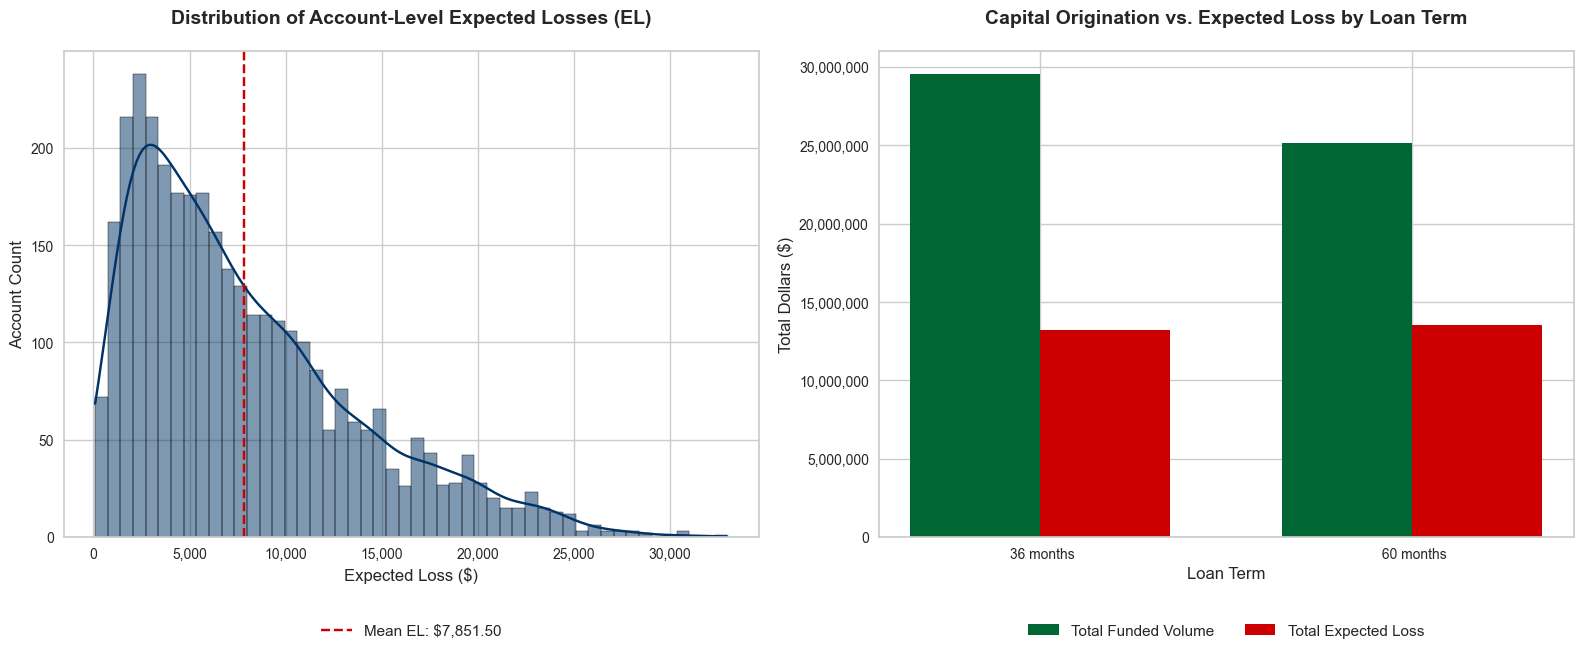

In [399]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# CHART 1: Distribution of Account-Level Expected Losses (Tail Risk)
sns.histplot(results_el['Expected_Loss (EL)'], bins=50, kde=True, ax=axes[0], color='#003366')
axes[0].set_title('Distribution of Account-Level Expected Losses (EL)', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Expected Loss ($)', fontsize=12)
axes[0].set_ylabel('Account Count', fontsize=12)

# Formatting
axes[0].axvline(results_el['Expected_Loss (EL)'].mean(), color='#cc0000', linestyle='--',  label=f"Mean EL: ${results_el['Expected_Loss (EL)'].mean():,.2f}")
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=False, ncol=1, fontsize=11)
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))


# CHART 2: Capital Origination vs Expected Loss by Loan Term Cohort
term_group = results_el.groupby('Loan_Term')[['Original_Amount', 'Expected_Loss (EL)']].sum().reset_index()
x = np.arange(len(term_group['Loan_Term']))
width = 0.35

axes[1].bar(x - width/2, term_group['Original_Amount'], width, label='Total Funded Volume', color='#006633')
axes[1].bar(x + width/2, term_group['Expected_Loss (EL)'], width, label='Total Expected Loss', color='#cc0000')
axes[1].set_title('Capital Origination vs. Expected Loss by Loan Term', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Loan Term', fontsize=12)
axes[1].set_ylabel('Total Dollars ($)', fontsize=12)

# Formatting
axes[1].set_xticks(x)
axes[1].set_xticklabels(term_group['Loan_Term'])
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=False, ncol=2, fontsize=11)

# Adjust layout to make room for bottom legends without clipping text
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

# Saving model and notebook

In [400]:
# ===============================================================================================
# SAVE LGD model artifacts
# ===============================================================================================

# Define deployment directory
# -----------------------------------------------------------------------------------------------
target_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"
os.makedirs(target_directory, exist_ok=True)

# Define output file path
# -----------------------------------------------------------------------------------------------
lgd_model_path = os.path.join(target_directory, "credit_risk_lgd_model.pkl")

# Consolidate all LGD artifacts into one object
# -----------------------------------------------------------------------------------------------
lgd_model_data = {
    # Stage 1: Recovery Classification Model
    "stage1_model": logit_lgd,
    # Optimal classification threshold
    "stage1_optimal_threshold": lgd_optimal_threshold,
    # Stage 2: Recovery Rate Regression Model
    "stage2_model": linear_lgd,
    # Feature metadata lists
    "stage1_feature_names": lgd_X_train.columns.tolist(),
    "stage2_feature_names": lgd_stage2_X_train.columns.tolist(),
    # Model performance summary
    "stage1_roc_auc": roc_auc_score(lgd_Y_test, lgd_y_pred_proba),
    "stage2_rmse": rmse_ols,
    "stage2_r2": r2_ols,
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "EAD_MAE": ead_mae,
    "EAD_RMSE": ead_rmse}

# Save model
# -----------------------------------------------------------------------------------------------
try:
    with open(lgd_model_path, "wb") as file:
        pickle.dump(lgd_model_data, file)

    print("🚀 LGD Model Successfully Saved")
    print("-" * 100)
    print(f"📂 File Path : {lgd_model_path}")
    print(f"📊 Stage 1 Model : Logistic Regression")
    print(f"📈 Stage 2 Model : OLS Regression")
    print(f"🎯 Optimal Threshold : {lgd_optimal_threshold:.4f}")

except Exception as e:
    print("❌ Failed to save LGD model")
    print(f"Error: {e}")

🚀 LGD Model Successfully Saved
----------------------------------------------------------------------------------------------------
📂 File Path : C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\credit_risk_lgd_model.pkl
📊 Stage 1 Model : Logistic Regression
📈 Stage 2 Model : OLS Regression
🎯 Optimal Threshold : 0.4232


In [401]:
# ===============================================================================================
# SAVE EAD model artifacts
# ===============================================================================================

# Deployment directory
# -----------------------------------------------------------------------------------------------
target_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"
os.makedirs(target_directory, exist_ok=True)

# Output file
# -----------------------------------------------------------------------------------------------
ead_model_path = os.path.join(target_directory, "credit_risk_ead_model.pkl")

# Consolidate deployment artifacts
# -----------------------------------------------------------------------------------------------
ead_model_data = {
    "ead_model": linear_ead,
    "ead_feature_names": ead_X_train.columns.tolist()}

# Save model
# -----------------------------------------------------------------------------------------------
try:
    with open(ead_model_path, "wb") as file:
        pickle.dump(ead_model_data, file)

    print("🚀 EAD model successfully saved!")
    print(f"📂 File Path : {ead_model_path}")

except Exception as e:
    print(f"❌ Failed to save EAD model: {e}")

🚀 EAD model successfully saved!
📂 File Path : C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\credit_risk_ead_model.pkl


In [402]:
import shutil

# Define source and destination
current_notebook_name = "N03 - Modelling loss given default (LGD), exposure at default (EAD) and expected loss (EL).ipynb"
destination_path = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"

# Ensure destination exists
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Perform the copy
try:
    # This looks for the file in the current working directory
    shutil.copy(current_notebook_name, os.path.join(destination_path, current_notebook_name))
    print(f"✅ Notebook successfully copied to: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{current_notebook_name}'.")
    print("👉 Make sure the filename matches exactly and you have saved (Ctrl+S) recently.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ An unexpected error occurred: 'N03 - Modelling loss given default (LGD), exposure at default (EAD) and expected loss (EL).ipynb' and 'C:\\Users\\danie\\Downloads\\Data Analytic\\lending_club_data\\model_deployment\\N03 - Modelling loss given default (LGD), exposure at default (EAD) and expected loss (EL).ipynb' are the same file
